In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [38]:
df1 = pd.read_csv('dados/dados_modelo1.csv')
df2 = pd.read_csv('dados/dados_modelo2.csv')
df3 = pd.read_csv('dados/dados_modelo3.csv')

### 1- Dividindo as features e a resposta

In [39]:


X1 = df1.drop('Reprovou', axis = 1)
y1 = df1['Reprovou']

X2 = df2.drop('Reprovou', axis = 1)
y2 = df2['Reprovou']

X3 = df3.drop('Reprovou', axis = 1)
y3 = df3['Reprovou']



### 2- Preenchendo nulos do tempo do quizz 3

In [40]:
X1['TempoQ3'] = X1['TempoQ3'].fillna(0)
X2['TempoQ3'] = X2['TempoQ3'].fillna(0)
X3['TempoQ3'] = X3['TempoQ3'].fillna(0)

### 3- Splitando o treino e o teste e treinando os 3 dataframes

Melhores parâmetros {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.7}
Recall da classe 0 no teste (XGB): 0.6363636363636364
Matriz de confusão (XGB):
 [[  7   4]
 [ 11 253]]


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:37:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


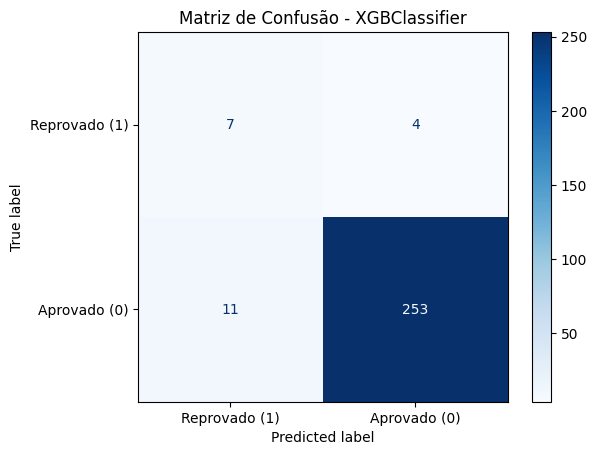

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, confusion_matrix

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Balanceamento com SMOTE
sm = SMOTE(random_state=42)
X1_train, y1_train = sm.fit_resample(X1_train, y1_train)

# Modelo base
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

# Grid COMPLETO
param_grid_xgb = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0]
}

# GridSearch focado em recall
grid_xgb = GridSearchCV(
    xgb, 
    param_grid_xgb, 
    cv=5, 
    scoring="recall", 
    n_jobs=-1, 
    verbose=0
)
grid_xgb.fit(X1_train, y1_train)

model1 = grid_xgb.best_params_
print("Melhores parâmetros", model1)
# Predições no teste
y1_pred = grid_xgb.predict(X1_test)

# Resultados finais (sem prints extras)
print("Recall da classe 0 no teste (XGB):", recall_score(y1_test, y1_pred))
print("Matriz de confusão (XGB):\n", confusion_matrix(y1_test, y1_pred, labels=[1,0]))

disp = ConfusionMatrixDisplay.from_predictions(
    y1_test,
    y1_pred,
    display_labels=["Reprovado (1)", "Aprovado (0)"],  
    cmap="Blues",
    values_format="d",
    labels = [1,0]
)

plt.title("Matriz de Confusão - XGBClassifier")
plt.show()


Melhores parâmetros {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 1.0}
Recall da classe 0 no teste (XGB): 0.6363636363636364
Matriz de confusão (XGB):
 [[  7   4]
 [ 16 248]]


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:37:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


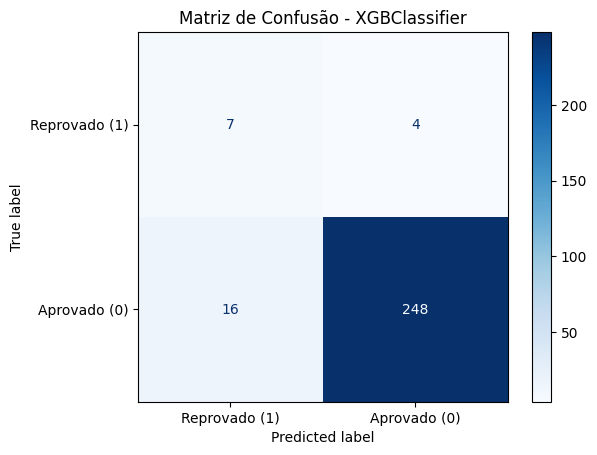

In [42]:
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, confusion_matrix

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Balanceamento com SMOTE
sm = SMOTE(random_state=42)
X2_train, y2_train = sm.fit_resample(X2_train, y2_train)

# Modelo base
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

# Grid COMPLETO
param_grid_xgb = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0]
}

# GridSearch focado em recall
grid_xgb = GridSearchCV(
    xgb, 
    param_grid_xgb, 
    cv=5, 
    scoring="recall", 
    n_jobs=-1, 
    verbose=0
)
grid_xgb.fit(X2_train, y2_train)

model2 = grid_xgb.best_params_
print("Melhores parâmetros", model2)
# Predições no teste
y2_pred = grid_xgb.predict(X2_test)

# Resultados finais (sem prints extras)
print("Recall da classe 0 no teste (XGB):", recall_score(y2_test, y2_pred))
print("Matriz de confusão (XGB):\n", confusion_matrix(y2_test, y2_pred, labels=[1,0]))

disp = ConfusionMatrixDisplay.from_predictions(
    y2_test,
    y2_pred,
    display_labels=["Reprovado (1)", "Aprovado (0)"],  
    cmap="Blues",
    values_format="d",
    labels = [1,0]
)

plt.title("Matriz de Confusão - XGBClassifier")
plt.show()


Melhores parâmetros {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.7}
Recall da classe 0 no teste (XGB): 0.7272727272727273
Matriz de confusão (XGB):
 [[  8   3]
 [ 23 241]]


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:37:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


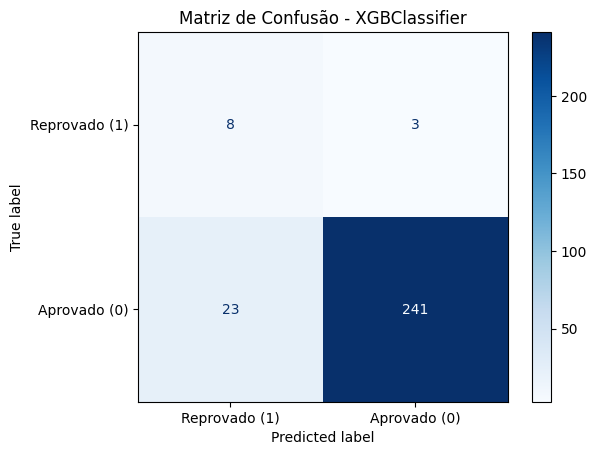

In [43]:
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, confusion_matrix

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

# Balanceamento com SMOTE
sm = SMOTE(random_state=42)
X3_train, y3_train = sm.fit_resample(X3_train, y3_train)

# Modelo base
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

# Grid COMPLETO
param_grid_xgb = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0]
}

# GridSearch focado em recall
grid_xgb = GridSearchCV(
    xgb, 
    param_grid_xgb, 
    cv=5, 
    scoring="recall", 
    n_jobs=-1, 
    verbose=0
)
grid_xgb.fit(X3_train, y3_train)

model3 = grid_xgb.best_params_
print("Melhores parâmetros", model3)
# Predições no teste
y3_pred = grid_xgb.predict(X3_test)

# Resultados finais (sem prints extras)
print("Recall da classe 0 no teste (XGB):", recall_score(y3_test, y3_pred))
print("Matriz de confusão (XGB):\n", confusion_matrix(y3_test, y3_pred, labels=[1,0]))

disp = ConfusionMatrixDisplay.from_predictions(
    y3_test,
    y3_pred,
    display_labels=["Reprovado (1)", "Aprovado (0)"],  
    cmap="Blues",
    values_format="d",
    labels = [1,0]
)

plt.title("Matriz de Confusão - XGBClassifier")
plt.show()
